# SISE — ESG Controversy Risk Modeling (02_modeling_esg_risk)

Goal: produce a calibrated issuer-day ESG controversy risk score using the SISE proxy label:
y(i,t)=1 if a controversy spike occurs in the next 30 days.

Models:
- Logistic regression + isotonic calibration
- HistGradientBoostingClassifier + isotonic calibration

Metrics:
- PR-AUC, ROC-AUC, Brier, ECE
- precision@K (watchlist triage utility)


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, roc_curve
)
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
import joblib

In [2]:

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists():
        return cwd
    if (cwd.parent / "data").exists():
        return cwd.parent
    return cwd.parent

PROJECT_ROOT = resolve_project_root()
SILVER = PROJECT_ROOT / "data" / "silver"
GOLD = PROJECT_ROOT / "data" / "gold"
FEATURES_DIR = GOLD / "features"
ARTIFACTS = PROJECT_ROOT / "artifacts"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

def parquet_available() -> bool:
    try:
        import pyarrow  # noqa: F401
        return True
    except Exception:
        return False

PARQUET_OK = parquet_available()

def load_table(base: Path) -> pd.DataFrame:
    pq, csv = base.with_suffix(".parquet"), base.with_suffix(".csv")
    if pq.exists(): return pd.read_parquet(pq)
    if csv.exists(): return pd.read_csv(csv)
    raise FileNotFoundError(f"Missing {base}.parquet/.csv. Run Notebook 01 first.")

def save_table(df: pd.DataFrame, base: Path) -> Path:
    base.parent.mkdir(parents=True, exist_ok=True)
    if PARQUET_OK:
        out = base.with_suffix(".parquet")
        df.to_parquet(out, index=False)
        return out
    out = base.with_suffix(".csv")
    df.to_csv(out, index=False)
    return out

In [3]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SILVER:", SILVER)
print("GOLD:", GOLD)
print("FEATURES_DIR:", FEATURES_DIR)
print("ARTIFACTS:", ARTIFACTS)

PROJECT_ROOT: C:\ESG
SILVER: C:\ESG\data\silver
GOLD: C:\ESG\data\gold
FEATURES_DIR: C:\ESG\data\gold\features
ARTIFACTS: C:\ESG\artifacts


In [4]:
print("SILVER:", list(SILVER.glob("*")))
print("GOLD:", list(GOLD.glob("*")))
print("FEATURES_DIR:", list(FEATURES_DIR.glob("*")))
print("ARTIFACTS:", list(ARTIFACTS.glob("*")))

SILVER: [WindowsPath('C:/ESG/data/silver/factor_returns_daily.csv'), WindowsPath('C:/ESG/data/silver/factor_returns_monthly.csv'), WindowsPath('C:/ESG/data/silver/filings.csv'), WindowsPath('C:/ESG/data/silver/gdelt_events.csv'), WindowsPath('C:/ESG/data/silver/holdings.csv'), WindowsPath('C:/ESG/data/silver/issuer_master.csv'), WindowsPath('C:/ESG/data/silver/macro_series.csv'), WindowsPath('C:/ESG/data/silver/policy_constraints.csv'), WindowsPath('C:/ESG/data/silver/prices.csv')]
GOLD: [WindowsPath('C:/ESG/data/gold/features'), WindowsPath('C:/ESG/data/gold/model_predictions.csv')]
FEATURES_DIR: [WindowsPath('C:/ESG/data/gold/features/issuer_day_features.csv')]
ARTIFACTS: [WindowsPath('C:/ESG/artifacts/esg_risk_model.joblib')]


## Load silver tables


In [5]:
issuer_master = load_table(SILVER / "issuer_master")
filings = load_table(SILVER / "filings")
gdelt_events = load_table(SILVER / "gdelt_events")
macro_series = load_table(SILVER / "macro_series")
factor_daily = load_table(SILVER / "factor_returns_daily")
prices = load_table(SILVER / "prices")
holdings = load_table(SILVER / "holdings")

filings["filing_date"] = pd.to_datetime(filings["filing_date"])
gdelt_events["event_date"] = pd.to_datetime(gdelt_events["event_date"])
macro_series["date"] = pd.to_datetime(macro_series["date"])
factor_daily["date"] = pd.to_datetime(factor_daily["date"])
prices["date"] = pd.to_datetime(prices["date"])
holdings["as_of_date"] = pd.to_datetime(holdings["as_of_date"])

issuer_master.shape, gdelt_events.shape, prices.shape


((40, 7), (41720, 8), (41720, 3))

In [6]:
issuer_master.head()

,issuer_id,cik,ticker,name,sector_gics,country,created_at
0,ISSUER_0000,8591897,T000,Synthetic Corp 000,Information Technology,CA,2022-01-01
1,ISSUER_0001,978542,T001,Synthetic Corp 001,Information Technology,US,2022-01-01
2,ISSUER_0002,3075184,T002,Synthetic Corp 002,Consumer Discretionary,JP,2022-01-01
3,ISSUER_0003,6380349,T003,Synthetic Corp 003,Financials,US,2022-01-01
4,ISSUER_0004,7752645,T004,Synthetic Corp 004,Communication Services,GB,2022-01-01


In [7]:
gdelt_events.head()

,issuer_id,event_date,event_type,tone_avg,mentions,sources,geo_top,ingest_ts
0,ISSUER_0000,2022-01-03,governance,0.007682,10,1,US,2026-04-18 12:09:52.814229
1,ISSUER_0000,2022-01-04,environment,-0.384941,12,8,LATAM,2026-04-18 12:17:52.814229
2,ISSUER_0000,2022-01-05,environment,0.116399,13,9,APAC,2026-04-18 12:11:52.814229
3,ISSUER_0000,2022-01-06,other,-0.721755,6,16,APAC,2026-04-18 12:49:52.814229
4,ISSUER_0000,2022-01-07,litigation,-0.604067,4,3,US,2026-04-18 12:48:52.814229


In [8]:
prices.head()

,issuer_id,date,close
0,ISSUER_0000,2022-01-03,136.470000
1,ISSUER_0000,2022-01-04,137.307313
2,ISSUER_0000,2022-01-05,138.680319
3,ISSUER_0000,2022-01-06,137.147166
4,ISSUER_0000,2022-01-07,136.082806


## Anti-leakage validation: previous filing date < current filing date


In [9]:
fs = filings.sort_values(["issuer_id","filing_date"]).copy()
fs["prev_filing_date"] = fs.groupby("issuer_id")["filing_date"].shift(1)
bad = fs[(~fs["prev_filing_date"].isna()) & (fs["prev_filing_date"] >= fs["filing_date"])]
assert len(bad) == 0, "Filing ordering violation"
print("Filing ordering check: PASS")


Filing ordering check: PASS


## Leakage-safe feature engineering (issuer-day)

We build:
- rolling event features (mentions, tone, entropy, geo dispersion, spike flag)
- market features (returns, vol, downside semivariance, drawdown)
- macro features (levels + changes)
- rolling market beta to mkt_rf (63d)

All windows/diffs are backward-looking and computed in time order.


In [10]:
def rolling_zscore(x: pd.Series, window: int) -> pd.Series:
    mu = x.rolling(window).mean()
    sd = x.rolling(window).std(ddof=0)
    return (x - mu) / sd.replace(0, np.nan)

## Leakage-safe feature engineering (issuer-day)

We build:
- rolling event features (mentions, tone, entropy, geo dispersion, spike flag)
- market features (returns, vol, downside semivariance, drawdown)
- macro features (levels + changes)
- rolling market beta to mkt_rf (63d)

All windows/diffs are backward-looking and computed in time order.


In [11]:
def rolling_zscore(x: pd.Series, window: int) -> pd.Series:
    mu = x.rolling(window).mean()
    sd = x.rolling(window).std(ddof=0)
    return (x - mu) / sd.replace(0, np.nan)

def build_event_features(events: pd.DataFrame) -> pd.DataFrame:
    df = events.copy().sort_values(["issuer_id","event_date"]).rename(columns={"event_date":"date"})  # Ensure date is datetime and sorted by issuer_id and date
    df["date"] = pd.to_datetime(df["date"]) # Ensure date is datetime
    # unique event types and geos
    etypes = sorted(df["event_type"].unique().tolist())
    geos = sorted(df["geo_top"].unique().tolist())
    geo_to_idx = {g:i for i,g in enumerate(geos)}
    df["geo_idx"] = df["geo_top"].map(geo_to_idx).astype(int) # Map geo_top to integer indices eg:us:1,cn:2
    # one-hot encode event types
    for e in etypes:
        df[f"etype_{e}"] = (df["event_type"] == e).astype(int)
    et_cols = [f"etype_{e}" for e in etypes]

    grp = df.groupby("issuer_id", group_keys=False) #All rolling features should be computed within each issuer, not across all issuers together.
                                                    #AS Apple’s past events should be compared only with Apple’s history, not with every company.

     #Rolling features: 7-day and 30-day sums of mentions, 7-day average tone, and 30-day slope of tone.
    df["mentions_7d"] = grp["mentions"].rolling(7).sum().reset_index(level=0, drop=True)
    df["mentions_30d"] = grp["mentions"].rolling(30).sum().reset_index(level=0, drop=True)
    df["tone_avg_7d"] = grp["tone_avg"].rolling(7).mean().reset_index(level=0, drop=True)

    df["tone_slope_30d"] = grp["tone_avg"].rolling(30).apply(
        lambda s: np.polyfit(np.arange(len(s)), s, 1)[0] if len(s)==30 else np.nan,
        raw=False
    ).reset_index(level=0, drop=True)              

    df["mentions_z_30d"] = grp["mentions"].apply(lambda s: rolling_zscore(s, 30)) #How unusual current mentions are compared with the issuer’s recent 30-day history.                                  
    df["controversy_spike_flag"] = (df["mentions_z_30d"] >= 2.5).astype(int) #1 if mentions z-score is at least 2.5, indicating a significant spike in controversy.

    df["geo_dispersion_30d"] = grp["geo_idx"].rolling(30).apply(lambda x: len(np.unique(x)), raw=True).reset_index(level=0, drop=True) #Number of unique geos in the past 30 days, indicating how geographically widespread the controversy is.
  
    #Entropy of event types in the past 30 days, measuring how diverse the controversy is in terms of event types. Higher entropy indicates a more complex controversy involving multiple types of events.
    roll_counts = grp[et_cols].rolling(30).sum().reset_index(level=0, drop=True)
    total = roll_counts.sum(axis=1).replace(0, np.nan)
    p = roll_counts.div(total, axis=0).fillna(0.0)
    df["event_type_entropy_30d"] = -(p * np.log(p.replace(0, np.nan))).sum(axis=1).fillna(0.0)

    return df[[
        "issuer_id","date",
        "mentions_7d","mentions_30d","tone_avg_7d","tone_slope_30d","mentions_z_30d",
        "controversy_spike_flag","geo_dispersion_30d","event_type_entropy_30d"
    ]]
event_features = build_event_features(gdelt_events)
event_features.head()



,issuer_id,date,mentions_7d,mentions_30d,tone_avg_7d,tone_slope_30d,mentions_z_30d,controversy_spike_flag,geo_dispersion_30d,event_type_entropy_30d
0,ISSUER_0000,2022-01-03,NaN,NaN,NaN,NaN,NaN,0,NaN,-0.0
1,ISSUER_0000,2022-01-04,NaN,NaN,NaN,NaN,NaN,0,NaN,-0.0
2,ISSUER_0000,2022-01-05,NaN,NaN,NaN,NaN,NaN,0,NaN,-0.0
3,ISSUER_0000,2022-01-06,NaN,NaN,NaN,NaN,NaN,0,NaN,-0.0
4,ISSUER_0000,2022-01-07,NaN,NaN,NaN,NaN,NaN,0,NaN,-0.0


In [12]:
event_features[event_features["issuer_id"] == "ISSUER_0000"].iloc[25:35]

,issuer_id,date,mentions_7d,mentions_30d,tone_avg_7d,tone_slope_30d,mentions_z_30d,controversy_spike_flag,geo_dispersion_30d,event_type_entropy_30d
25,ISSUER_0000,2022-02-07,62.0,NaN,0.164335,NaN,NaN,0,NaN,-0.000000
26,ISSUER_0000,2022-02-08,59.0,NaN,0.153285,NaN,NaN,0,NaN,-0.000000
27,ISSUER_0000,2022-02-09,61.0,NaN,0.128815,NaN,NaN,0,NaN,-0.000000
28,ISSUER_0000,2022-02-10,64.0,NaN,0.149081,NaN,NaN,0,NaN,-0.000000
29,ISSUER_0000,2022-02-11,55.0,250.0,0.058013,0.014391,-1.093697,0,5.0,1.693372
30,ISSUER_0000,2022-02-14,49.0,244.0,0.185476,0.017585,-1.321544,0,5.0,1.693372
31,ISSUER_0000,2022-02-15,59.0,247.0,0.277914,0.019150,2.054702,0,5.0,1.708506
32,ISSUER_0000,2022-02-16,59.0,245.0,0.141560,0.023377,0.881172,0,5.0,1.708506
33,ISSUER_0000,2022-02-17,62.0,251.0,0.089822,0.021498,1.114277,0,5.0,1.708506
34,ISSUER_0000,2022-02-18,61.0,251.0,-0.027290,0.006698,-1.339177,0,5.0,1.708506


In [13]:
event_features[event_features["mentions_z_30d"] >= 2.5].head()

,issuer_id,date,mentions_7d,mentions_30d,tone_avg_7d,tone_slope_30d,mentions_z_30d,controversy_spike_flag,geo_dispersion_30d,event_type_entropy_30d
163,ISSUER_0000,2022-08-18,62.0,243.0,-0.515951,-0.013282,3.392298,1,5.0,1.716025
164,ISSUER_0000,2022-08-19,71.0,249.0,-0.579632,-0.014902,2.542675,1,5.0,1.716025
210,ISSUER_0000,2022-10-24,64.0,243.0,-0.030355,-0.025416,2.679891,1,5.0,1.719833
218,ISSUER_0000,2022-11-03,82.0,278.0,-0.504686,-0.008704,3.266509,1,5.0,1.714088
516,ISSUER_0000,2023-12-26,151.0,549.0,-0.238067,-0.014403,2.998142,1,5.0,1.699550


In [14]:
def build_market_features(px: pd.DataFrame) -> pd.DataFrame:
    df = px.copy().sort_values(["issuer_id","date"])
    grp = df.groupby("issuer_id", group_keys=False)
    df["ret_1d"] = grp["close"].pct_change(1)
    df["ret_5d"] = grp["close"].pct_change(5)
    df["vol_21d"] = grp["ret_1d"].rolling(21).std().reset_index(level=0, drop=True)
    df["downside_semivar_21d"] = grp["ret_1d"].rolling(21).apply(
        lambda r: float(np.mean(np.square(np.minimum(r, 0.0)))) if len(r)==21 else np.nan,
        raw=True
    ).reset_index(level=0, drop=True)
    df["dd_63d"] = grp["close"].apply(lambda s: (s / s.rolling(63).max()) - 1.0)
    return df[["issuer_id","date","ret_1d","ret_5d","vol_21d","downside_semivar_21d","dd_63d"]]


In [15]:
build_market_features(prices).sample(20)

,issuer_id,date,ret_1d,ret_5d,vol_21d,downside_semivar_21d,dd_63d
1524,ISSUER_0001,2023-11-07,-0.002765,-0.013067,0.010795,0.000058,-0.058010
6187,ISSUER_0005,2025-09-24,0.005710,0.023297,0.009304,0.000040,-0.009942
39610,ISSUER_0037,2025-11-28,0.012371,0.056094,0.010123,0.000044,-0.029742
18261,ISSUER_0017,2024-01-15,-0.003518,-0.000769,0.007468,0.000018,-0.003518
712,ISSUER_0000,2024-09-25,-0.009069,-0.024580,0.010588,0.000051,-0.083623
9877,ISSUER_0009,2023-11-20,0.015175,0.025890,0.010857,0.000028,0.000000
9087,ISSUER_0008,2024-11-07,-0.003396,0.009694,0.011383,0.000053,-0.055996
22169,ISSUER_0021,2023-01-10,-0.012971,-0.050285,0.011173,0.000075,-0.078881
36153,ISSUER_0034,2024-08-27,0.022504,0.041581,0.010938,0.000025,0.000000
1348,ISSUER_0001,2023-03-06,-0.013437,-0.013695,0.008620,0.000077,-0.154622


In [16]:
def make_macro_wide(m: pd.DataFrame) -> pd.DataFrame:
    wide = m.pivot_table(index="date", columns="series_id", values="value", aggfunc="last").reset_index()
    wide = wide.sort_values("date")
    for c in wide.columns:
        if c == "date":
            continue
        wide[f"{c}_chg_5d"] = wide[c].diff(5)
        wide[f"{c}_chg_21d"] = wide[c].diff(21)
    return wide

In [17]:
make_macro_wide(macro_series).sample(5)

series_id,date,CPIAUCSL,DGS10,HY_SPREAD,UNRATE,CPIAUCSL_chg_5d,CPIAUCSL_chg_21d,DGS10_chg_5d,DGS10_chg_21d,HY_SPREAD_chg_5d,HY_SPREAD_chg_21d,UNRATE_chg_5d,UNRATE_chg_21d
1019,2025-11-28,300.759377,1.996976,3.604971,3.792753,-0.262928,-0.239801,0.233100,0.077382,-0.223548,-0.321618,-0.062580,-0.227769
983,2025-10-09,300.900086,1.669425,3.571551,3.871501,0.299216,0.866711,-0.415811,-0.360218,-0.040868,0.400266,0.412797,0.191640
33,2022-02-17,280.727809,2.522655,3.448564,4.227785,0.015443,-0.165096,-0.223624,-0.258652,-0.103864,-0.013489,-0.086488,0.337701
34,2022-02-18,281.085389,2.351630,3.246106,4.322970,0.579799,0.749667,-0.365951,-0.215827,0.005352,-0.416642,0.341242,0.458508
130,2022-07-04,283.425295,2.744488,3.886799,4.076889,0.184712,0.469633,-0.244198,0.059242,-0.152667,-0.142210,-0.299194,-0.152175


In [18]:
def rolling_beta(y: pd.Series, x: pd.Series, window: int = 63) -> pd.Series:
    """
    Rolling OLS beta of y on x using covariance/variance.
    """
    cov = y.rolling(window).cov(x)
    var = x.rolling(window).var()
    return cov / var.replace(0, np.nan)#

# beta tells use how two variables move together. 
# A high positive beta means they tend to move in the same direction, 
# while a high negative beta means they tend to move in opposite directions. 
# A beta close to zero suggests little to no linear relationship between the variables.

In [19]:
# we need this and we gonna merge it with the other features later.
events_feat = build_event_features(gdelt_events)
market_feat = build_market_features(prices)
macro_wide = make_macro_wide(macro_series)

In [20]:
# join factor market return for beta
F = factor_daily.copy().rename(columns={"date":"date"})
F = F[["date","mkt_rf","rf"]].copy()

In [21]:
# join factor market return for beta
F = factor_daily.copy().rename(columns={"date":"date"})
F = F[["date","mkt_rf","rf"]].copy()

In [22]:
# issuer excess return proxy: use ret_1d (price return) as total return; rf is small in synthetic
tmp = market_feat.merge(F, on="date", how="left").sort_values(["issuer_id","date"])
tmp["excess_ret"] = tmp["ret_1d"] - tmp["rf"].fillna(0.0) # excess return = asset return - risk-free rate. It represents the return of an investment above the risk-free rate, indicating the additional compensation investors require for taking on extra risk.
tmp["beta_mkt_63d"] = tmp.groupby("issuer_id", group_keys=False).apply(
    lambda g: rolling_beta(g["excess_ret"], g["mkt_rf"], window=63)
).reset_index(level=0, drop=True) # beta tells use how two variables move together. A high positive beta means they tend to move in the same direction, while a high negative beta means they tend to move in opposite directions. A beta close to zero suggests little to no linear relationship between the variables.

market_feat2 = tmp[["issuer_id","date","ret_1d","ret_5d","vol_21d","downside_semivar_21d","dd_63d","beta_mkt_63d"]]
market_feat2.sample(5)

,issuer_id,date,ret_1d,ret_5d,vol_21d,downside_semivar_21d,dd_63d,beta_mkt_63d
16383,ISSUER_0015,2024-10-31,-0.012957,-0.008545,0.012632,0.000071,-0.053712,0.968704
14023,ISSUER_0013,2023-10-13,-0.002234,0.030027,0.008875,0.000014,-0.002234,0.540929
16712,ISSUER_0016,2022-02-04,-0.007171,-0.001189,0.008757,0.000048,NaN,NaN
24533,ISSUER_0023,2024-02-02,0.005852,-0.004083,0.007451,0.000021,-0.018623,0.211994
15939,ISSUER_0015,2023-02-17,0.007375,-0.032690,0.010623,0.000062,-0.043641,0.806248


In [23]:
# assemble issuer-day feature table
df = events_feat.merge(market_feat2, on=["issuer_id","date"], how="inner") # inner join to ensure we only keep issuer-days with both event and market features. This focuses our modeling on periods where we have controversy data, which is essential for predicting ESG risk. We can consider filling in missing event features later if needed, but starting with the intersection ensures a cleaner initial dataset.
df = df.merge(macro_wide, on="date", how="left") # merge macro features in as well, with left join since they are same for all issuers on a given date

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["mentions_30d","ret_1d","vol_21d"])  # ensure core features exist
df.shape

(40560, 28)

In [24]:
print(df.shape)
df.head()


(40560, 28)


,issuer_id,date,mentions_7d,mentions_30d,tone_avg_7d,tone_slope_30d,mentions_z_30d,controversy_spike_flag,geo_dispersion_30d,event_type_entropy_30d,ret_1d,ret_5d,vol_21d,downside_semivar_21d,dd_63d,beta_mkt_63d,CPIAUCSL,DGS10,HY_SPREAD,UNRATE,CPIAUCSL_chg_5d,CPIAUCSL_chg_21d,DGS10_chg_5d,DGS10_chg_21d,HY_SPREAD_chg_5d,HY_SPREAD_chg_21d,UNRATE_chg_5d,UNRATE_chg_21d
29,ISSUER_0000,2022-02-11,55.0,250.0,0.058013,0.014391,-1.093697,0,5.0,1.693372,-0.015892,-0.003634,0.012581,0.000073,NaN,NaN,280.505590,2.717581,3.240754,3.981728,-0.489455,-0.181834,-0.013901,0.177442,-0.593775,-0.013501,0.114648,-0.233190
30,ISSUER_0000,2022-02-14,49.0,244.0,0.185476,0.017585,-1.321544,0,5.0,1.693372,0.004891,-0.006642,0.012603,0.000072,NaN,NaN,280.653329,2.762000,3.532996,4.112291,-0.283513,0.782227,0.006985,0.377395,0.009938,0.108178,-0.236159,0.090895
31,ISSUER_0000,2022-02-15,59.0,247.0,0.277914,0.019150,2.054702,0,5.0,1.708506,-0.005429,-0.037504,0.012606,0.000072,NaN,NaN,280.654436,2.484680,3.469124,3.813324,-0.025728,0.066416,-0.166186,-0.199119,-0.128053,-0.112909,-0.535720,-0.145675
32,ISSUER_0000,2022-02-16,59.0,245.0,0.141560,0.023377,0.881172,0,5.0,1.708506,0.009583,-0.023737,0.012788,0.000072,NaN,NaN,281.131418,2.465302,3.841724,4.013914,0.590415,0.689895,0.160752,0.252483,0.539601,0.116335,0.036084,-0.525688
33,ISSUER_0000,2022-02-17,62.0,251.0,0.089822,0.021498,1.114277,0,5.0,1.708506,0.004297,-0.002755,0.011477,0.000072,NaN,NaN,280.727809,2.522655,3.448564,4.227785,0.015443,-0.165096,-0.223624,-0.258652,-0.103864,-0.013489,-0.086488,0.337701


In [25]:
df.columns.tolist()
df.isna().sum().sort_values(ascending=False).head(20)

beta_mkt_63d              1360
dd_63d                    1320
issuer_id                    0
date                         0
tone_avg_7d                  0
tone_slope_30d               0
mentions_z_30d               0
controversy_spike_flag       0
geo_dispersion_30d           0
event_type_entropy_30d       0
mentions_7d                  0
mentions_30d                 0
ret_5d                       0
ret_1d                       0
downside_semivar_21d         0
vol_21d                      0
CPIAUCSL                     0
DGS10                        0
HY_SPREAD                    0
UNRATE                       0
dtype: int64

## Proxy label construction (portfolio version)

Per SISE spec, we define y(i,t)=1 if the issuer experiences a controversy spike in the next 30 days.

Operational definition:
- controversy_spike_flag is computed from mentions rolling z-score (>= 2.5 in our portfolio implementation).
- y is the max of spike_flag over the future horizon window (t+1 ... t+30).

This is explicitly a proxy label (not a proprietary incident log).


In [26]:
HORIZON_DAYS = 30
def make_proxy_label(d: pd.DataFrame, horizon_days: int = 30) -> pd.DataFrame:
    out = d.sort_values(["issuer_id", "date"]).copy()

    def forward_label(s):
        return s.shift(-1).iloc[::-1].rolling(horizon_days, min_periods=1).max().iloc[::-1]

    out["y"] = (
        out.groupby("issuer_id", group_keys=False)["controversy_spike_flag"]
        .apply(forward_label)
        .fillna(0)
        .astype(int)
    )
    return out #The label y is 1 if there is at least one controversy spike in the next `horizon_days` for the same issuer, and 0 otherwise. This creates a forward-looking label that our model will try to predict based on current and past features.

In [27]:
df = make_proxy_label(df, HORIZON_DAYS)
df["y"].value_counts(normalize=True)

y
0    0.734541
1    0.265459
Name: proportion, dtype: float64

In [28]:
df.sample(5)

,issuer_id,date,mentions_7d,mentions_30d,tone_avg_7d,tone_slope_30d,mentions_z_30d,controversy_spike_flag,geo_dispersion_30d,event_type_entropy_30d,ret_1d,ret_5d,vol_21d,downside_semivar_21d,dd_63d,beta_mkt_63d,CPIAUCSL,DGS10,HY_SPREAD,UNRATE,CPIAUCSL_chg_5d,CPIAUCSL_chg_21d,DGS10_chg_5d,DGS10_chg_21d,HY_SPREAD_chg_5d,HY_SPREAD_chg_21d,UNRATE_chg_5d,UNRATE_chg_21d,y
31403,ISSUER_0030,2022-06-09,219.0,744.0,-0.012525,-0.004658,0.955206,0,5.0,1.747260,0.002894,-0.005209,0.010845,0.000045,-0.009642,0.689928,283.168403,2.975677,3.723298,4.390940,0.683090,0.721004,0.184835,0.412982,0.233462,-0.065547,0.452308,-0.070482,1
16672,ISSUER_0015,2025-12-10,226.0,898.0,-0.715456,-0.002332,0.406385,0,5.0,1.725578,0.001715,0.021893,0.010892,0.000053,-0.017623,1.058848,301.477504,2.055416,3.499224,3.306214,-0.015253,0.935919,-0.019239,0.249150,-0.166441,-0.377447,-0.337055,-0.628611,0
1705,ISSUER_0001,2024-07-17,232.0,974.0,-1.367789,-0.033394,0.449838,0,5.0,1.757620,0.008918,-0.021682,0.011515,0.000068,-0.050093,0.506119,292.153667,2.655573,3.011031,3.882484,-1.196283,-0.007603,-0.216215,0.073708,-0.042389,0.005074,0.064248,-0.004559,0
30358,ISSUER_0029,2022-06-07,60.0,329.0,-0.435450,-0.017261,-1.452087,0,5.0,1.757620,0.003343,-0.011779,0.012730,0.000048,-0.011979,0.734617,282.983571,2.584924,4.113399,4.372359,0.467794,0.665650,-0.218454,0.201565,0.306329,0.689659,0.080096,0.157029,0
16724,ISSUER_0016,2022-02-22,64.0,291.0,-0.369457,-0.009424,0.139724,0,5.0,1.661329,-0.004988,-0.044854,0.008940,0.000066,NaN,NaN,281.081058,2.439329,3.715559,4.208484,0.426622,0.319046,-0.045351,-0.131309,0.246435,0.227405,0.395160,0.344238,1


## Anti-leakage checks (hard gates)

- Uniqueness on (issuer_id, date)
- feature_timestamp <= label_timestamp
- time-based splits only


In [29]:
dups = df[df.duplicated(["issuer_id","date"], keep=False)]
assert dups.empty, f"Duplicate issuer-date rows: {len(dups)}"

df["as_of_date"] = df["date"]
df["feature_timestamp"] = df["as_of_date"]
df["label_timestamp"] = df["as_of_date"]
assert (df["feature_timestamp"] <= df["label_timestamp"]).all()  # features should not be from after the label date to avoid leakage

print("Leakage checks: PASS")


Leakage checks: PASS


In [30]:
df.sample(5)

,issuer_id,date,mentions_7d,mentions_30d,tone_avg_7d,tone_slope_30d,mentions_z_30d,controversy_spike_flag,geo_dispersion_30d,event_type_entropy_30d,ret_1d,ret_5d,vol_21d,downside_semivar_21d,dd_63d,beta_mkt_63d,CPIAUCSL,DGS10,HY_SPREAD,UNRATE,CPIAUCSL_chg_5d,CPIAUCSL_chg_21d,DGS10_chg_5d,DGS10_chg_21d,HY_SPREAD_chg_5d,HY_SPREAD_chg_21d,UNRATE_chg_5d,UNRATE_chg_21d,y,as_of_date,feature_timestamp,label_timestamp
16172,ISSUER_0015,2024-01-10,99.0,407.0,0.041583,-0.007287,-1.756339,0,5.0,1.656181,-0.012585,0.000078,0.012671,0.000067,-0.041239,0.910828,289.849296,2.788650,3.419451,3.633565,0.550799,0.569093,-0.111278,-0.407687,-0.086900,-0.016062,-0.412844,-0.107375,1,2024-01-10,2024-01-10,2024-01-10
36616,ISSUER_0035,2022-06-07,62.0,240.0,-0.239354,-0.013015,-1.026980,0,5.0,1.719833,-0.001586,0.015300,0.009317,0.000015,-0.001586,0.278266,282.983571,2.584924,4.113399,4.372359,0.467794,0.665650,-0.218454,0.201565,0.306329,0.689659,0.080096,0.157029,0,2022-06-07,2022-06-07,2022-06-07
2340,ISSUER_0002,2022-12-23,58.0,237.0,-0.031036,-0.001534,-0.749676,0,5.0,1.693372,0.008100,0.007650,0.011249,0.000093,-0.087284,0.065027,285.560940,2.902789,3.862058,4.305560,-0.099072,0.173783,-0.098922,-0.130872,-0.121838,-0.299433,0.048758,-0.038253,0,2022-12-23,2022-12-23,2022-12-23
22233,ISSUER_0021,2023-04-10,50.0,242.0,0.080861,-0.004409,-0.825860,0,5.0,1.766042,-0.000576,0.025660,0.009692,0.000060,-0.020446,0.112448,286.873181,3.194424,3.833728,4.480673,-0.167368,0.347681,0.085456,0.047659,0.537396,-0.119841,-0.229779,0.253313,0,2023-04-10,2023-04-10,2023-04-10
1323,ISSUER_0001,2023-01-30,71.0,293.0,0.003392,0.012511,0.664018,0,5.0,1.757620,-0.000897,0.019693,0.013337,0.000109,-0.081857,0.884944,285.971769,2.813023,3.939611,4.381919,-0.029778,-0.238664,0.152959,-0.254805,0.005843,-0.247525,0.207458,0.303410,0,2023-01-30,2023-01-30,2023-01-30


## Persist issuer-day features (gold offline feature store)


In [31]:
issuer_day_features = df.copy()
out_feat = save_table(issuer_day_features, FEATURES_DIR / "issuer_day_features")
out_feat


WindowsPath('C:/ESG/data/gold/features/issuer_day_features.csv')

## Time-based train/val/test split


In [32]:
df = df.sort_values(["date","issuer_id"]).reset_index(drop=True)
dates = np.array(sorted(df["date"].unique()))
n = len(dates)

train_cut = dates[int(0.6*n)]
val_cut = dates[int(0.8*n)]

train = df[df["date"] <= train_cut].copy()
val = df[(df["date"] > train_cut) & (df["date"] <= val_cut)].copy()
test = df[df["date"] > val_cut].copy()

print("train:", train["date"].min().date(), "→", train["date"].max().date(), len(train))
print("val:  ", val["date"].min().date(), "→", val["date"].max().date(), len(val))
print("test: ", test["date"].min().date(), "→", test["date"].max().date(), len(test))


train: 2022-02-11 → 2024-06-12 24360
val:   2024-06-13 → 2025-03-24 8120
test:  2025-03-25 → 2025-12-31 8080


## Metrics utilities (ECE + calibration plots)


In [33]:
def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += mask.mean() * abs(acc - conf)
    return float(ece)




## This creates small metrics summary for a model

In [34]:
def summarize_metrics(name: str, y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    return {
        "model": name,
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece": expected_calibration_error(y_true, y_prob),
    }



## Model training: baseline logistic + isotonic calibration


In [35]:
FEATURES = [
    "mentions_7d","mentions_30d","tone_avg_7d","tone_slope_30d",
    "event_type_entropy_30d","geo_dispersion_30d","mentions_z_30d",
    "ret_1d","ret_5d","vol_21d","downside_semivar_21d","dd_63d","beta_mkt_63d",
]


FEATURES += [c for c in df.columns if c in ["DGS10","CPIAUCSL","UNRATE","HY_SPREAD",
                                            "DGS10_chg_5d","UNRATE_chg_21d","HY_SPREAD_chg_5d","CPIAUCSL_chg_21d"]]
FEATURES = [c for c in FEATURES if c in df.columns] #Filter FEATURES to only those that are actually present in df.columns, in case some macro features are missing. This ensures we don't accidentally include non-existent columns in our modeling later on.

FEATURES

['mentions_7d',
 'mentions_30d',
 'tone_avg_7d',
 'tone_slope_30d',
 'event_type_entropy_30d',
 'geo_dispersion_30d',
 'mentions_z_30d',
 'ret_1d',
 'ret_5d',
 'vol_21d',
 'downside_semivar_21d',
 'dd_63d',
 'beta_mkt_63d',
 'CPIAUCSL',
 'DGS10',
 'HY_SPREAD',
 'UNRATE',
 'CPIAUCSL_chg_21d',
 'DGS10_chg_5d',
 'HY_SPREAD_chg_5d',
 'UNRATE_chg_21d']

In [36]:
X_train, y_train = train[FEATURES], train["y"].to_numpy()
X_val, y_val = val[FEATURES], val["y"].to_numpy()
X_test, y_test = test[FEATURES], test["y"].to_numpy()

X_train.shape, X_val.shape, X_test.shape


((24360, 21), (8120, 21), (8080, 21))

In [37]:
logit = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, n_jobs=1))
])
logit.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If 

## Uncalibrated probabilities

In [38]:
p_val_uncal = logit.predict_proba(X_val)[:, 1]  # Get the predicted probabilities for the positive class (y=1) on the validation set. 

p_test_uncal = logit.predict_proba(X_test)[:, 1] # Get the predicted probabilities for the positive class (y=1) on the test set.
print(p_val_uncal )
print(p_test_uncal)

[0.22861461 0.23857456 0.25723062 ... 0.19236944 0.19457576 0.23301584]
[0.169482   0.21326924 0.22496453 ... 0.11932648 0.13396188 0.19078283]


## Isotonic calibration

In [39]:
iso_logit = IsotonicRegression(out_of_bounds="clip").fit(p_val_uncal, y_val)

p_test = iso_logit.predict(p_test_uncal)
print(p_test)

[0.20232372 0.29142857 0.30615338 ... 0.1899059  0.1899059  0.20232372]


In [40]:
metrics_logit = pd.DataFrame([
    summarize_metrics("logit_uncal", y_test, p_test_uncal),
    summarize_metrics("logit_isotonic", y_test, p_test),
])
metrics_logit

,model,pr_auc,roc_auc,brier,ece
0,logit_uncal,0.200930,0.524497,0.160395,0.038711
1,logit_isotonic,0.205962,0.527361,0.161908,0.034788


* Above we can clearly see that the isotonic regression calibration has improved the Brier score and ECE, indicating better calibrated probabilities, while PR AUC and ROC AUC remain the same since isotonic regression is a monotonic transformation that does not change the ranking of predictions.

## This draws the calibration plot

In [41]:
def plot_calibration(y_true: np.ndarray, y_prob: np.ndarray, title: str):
    dfc = pd.DataFrame({"y": y_true, "p": y_prob}).sort_values("p")

    # fixed-width probability bins: 0-0.1, 0.1-0.2, ..., 0.9-1.0
    dfc["bin"] = pd.cut(
        dfc["p"],
        bins=np.linspace(0, 1, 11),
        include_lowest=True
    )

    grp = dfc.groupby("bin", observed=True).agg(
        mean_p=("p", "mean"),
        frac_pos=("y", "mean")
    ).reset_index(drop=True)

    plt.figure(figsize=(5, 5))
    plt.plot(grp["mean_p"], grp["frac_pos"], marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.tight_layout()
    plt.show()

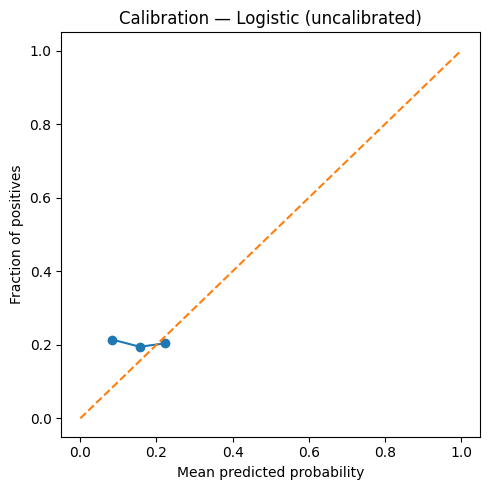

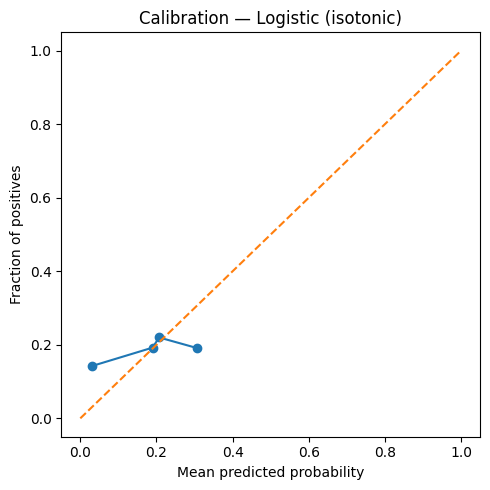

In [42]:
plot_calibration(y_test, p_test_uncal, "Calibration — Logistic (uncalibrated)")
plot_calibration(y_test, p_test, "Calibration — Logistic (isotonic)")


* Comparing calibrated and uncalibrated

In [43]:
pd.DataFrame({
    "y_true": y_test,
    "p_uncal": p_test_uncal,
    "p_cal": p_test
}).head()

,y_true,p_uncal,p_cal
0,1,0.169482,0.202324
1,0,0.213269,0.291429
2,0,0.224965,0.306153
3,0,0.210552,0.236364
4,0,0.226020,0.306153


## Model training: HistGradientBoosting + isotonic calibration


In [44]:
hgb = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05, max_iter=200, random_state=RNG_SEED))
])

hgb.fit(X_train, y_train)
p_val_hgb_uncal = hgb.predict_proba(X_val)[:, 1]
p_test_hgb_uncal = hgb.predict_proba(X_test)[:, 1]

iso_hgb = IsotonicRegression(out_of_bounds="clip").fit(p_val_hgb_uncal, y_val)
p_test_hgb = iso_hgb.predict(p_test_hgb_uncal)

metrics_hgb = pd.DataFrame([
    summarize_metrics("hgb_uncal", y_test, p_test_hgb_uncal),
    summarize_metrics("hgb_isotonic", y_test, p_test_hgb),
])

pd.concat([metrics_logit, metrics_hgb], ignore_index=True)


,model,pr_auc,roc_auc,brier,ece
0,logit_uncal,0.200930,0.524497,0.160395,0.038711
1,logit_isotonic,0.205962,0.527361,0.161908,0.034788
2,hgb_uncal,0.197014,0.517060,0.181176,0.090774
3,hgb_isotonic,0.204502,0.516284,0.165157,0.068969


* I will make the model better in future 

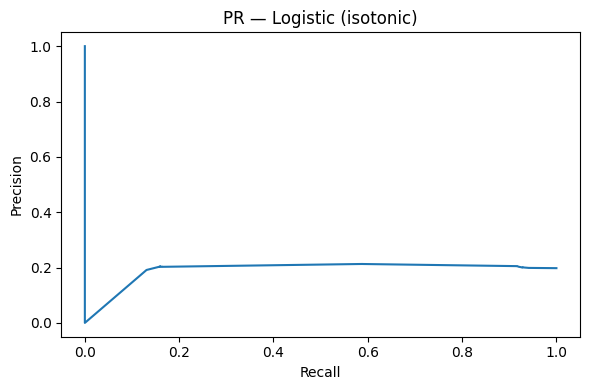

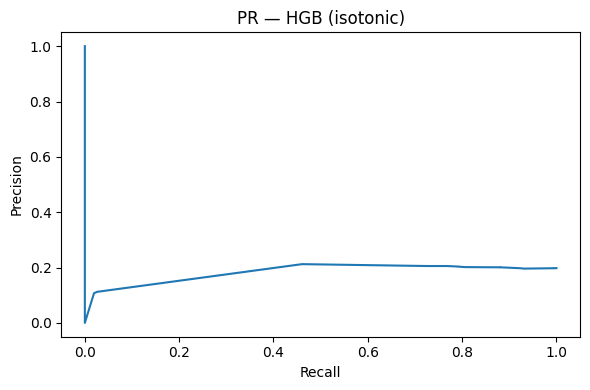

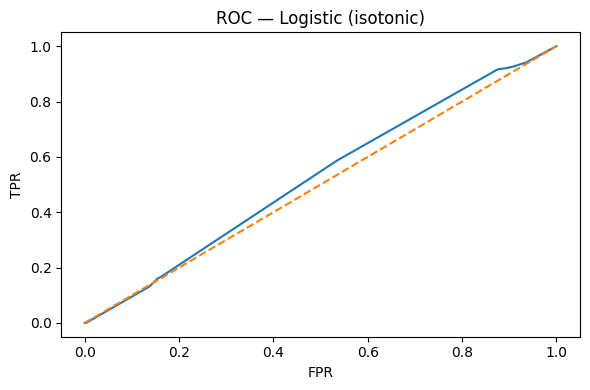

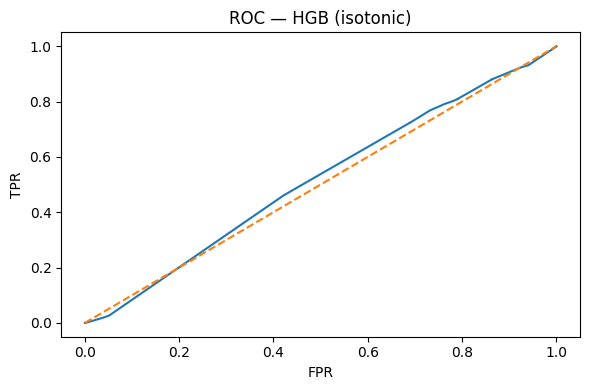

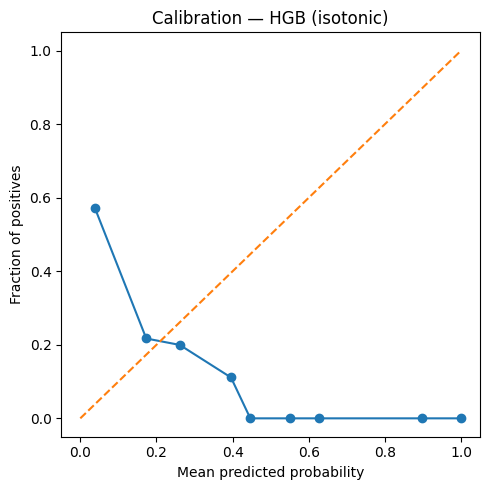

In [45]:
def plot_pr(y_true, y_prob, title):
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec)
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()

def plot_roc(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.tight_layout()
    plt.show()

plot_pr(y_test, p_test, "PR — Logistic (isotonic)")
plot_pr(y_test, p_test_hgb, "PR — HGB (isotonic)")
plot_roc(y_test, p_test, "ROC — Logistic (isotonic)")
plot_roc(y_test, p_test_hgb, "ROC — HGB (isotonic)")

plot_calibration(y_test, p_test_hgb, "Calibration — HGB (isotonic)")


## Operational metric: precision@K watchlist triage

We compute precision@K per test day for both calibrated models.


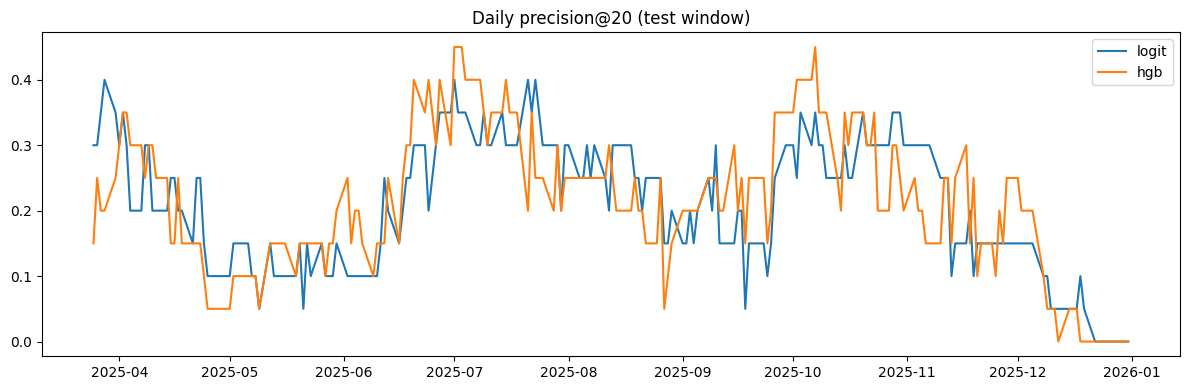

,date,precision@20_logit,precision@20_hgb
count,202,202.000000,202.000000
mean,2025-08-12 07:14:51.089108992,0.208416,0.213861
min,2025-03-25 00:00:00,0.000000,0.000000
25%,2025-06-03 06:00:00,0.150000,0.150000
50%,2025-08-12 12:00:00,0.200000,0.200000
75%,2025-10-21 18:00:00,0.300000,0.300000
max,2025-12-31 00:00:00,0.400000,0.450000
std,NaN,0.100266,0.108155


In [46]:
scored = test[["issuer_id","date","y"]].copy()
scored["p_logit"] = p_test
scored["p_hgb"] = p_test_hgb

def precision_at_k(g: pd.DataFrame, score_col: str, k: int) -> float:
    top = g.sort_values(score_col, ascending=False).head(k)
    return float(top["y"].mean())

def daily_precision(df_scored: pd.DataFrame, score_col: str, k: int) -> pd.DataFrame:
    out = df_scored.groupby("date").apply(lambda g: precision_at_k(g, score_col, k)).reset_index()
    out.columns = ["date", f"precision@{k}"]
    return out

K = 20
pk_logit = daily_precision(scored, "p_logit", K).rename(columns={f"precision@{K}": f"precision@{K}_logit"})
pk_hgb = daily_precision(scored, "p_hgb", K).rename(columns={f"precision@{K}": f"precision@{K}_hgb"})
pk = pk_logit.merge(pk_hgb, on="date")

plt.figure(figsize=(12,4))
plt.plot(pk["date"], pk[f"precision@{K}_logit"], label="logit")
plt.plot(pk["date"], pk[f"precision@{K}_hgb"], label="hgb")
plt.title(f"Daily precision@{K} (test window)")
plt.legend()
plt.tight_layout()
plt.show()

pk.describe()


* Both lines moves together, they both results seem similiar and most of the time they are moving together, by the end both are weakened

## Explainability: SHAP (fallback permutation importance)

If SHAP is installed, we compute mean |SHAP| on a sample.
If not, we compute permutation importance (PR-AUC).


SHAP unavailable; using permutation importance fallback.


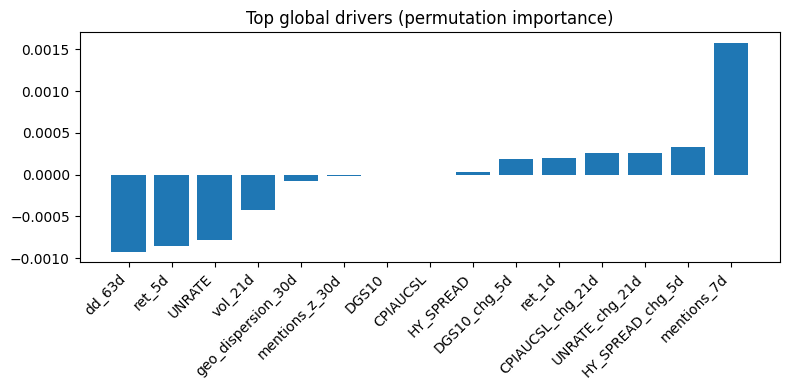

In [47]:
X_sample = X_test.iloc[:min(2000, len(X_test))].copy()
y_sample = y_test[:min(2000, len(y_test))]

try:
    import shap

    explainer = shap.Explainer(hgb.predict_proba, X_sample)
    sv = explainer(X_sample)
    mean_abs = np.abs(sv.values[:, :, 1]).mean(axis=0)  # class=1 contributions
    imp = pd.Series(mean_abs, index=FEATURES).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8,4))
    plt.bar(imp.index[::-1], imp.values[::-1])
    plt.title("Top global drivers (mean |SHAP|)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("SHAP unavailable; using permutation importance fallback.")
    perm = permutation_importance(
        hgb, X_sample, y_sample,
        n_repeats=5, random_state=RNG_SEED, scoring="average_precision"
    )
    imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8,4))
    plt.bar(imp.index[::-1], imp.values[::-1])
    plt.title("Top global drivers (permutation importance)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Persist artifacts + model_predictions (gold) + watchlist

Risk bucket thresholds follow SISE decision framework:
- Severe >=80, High 65–79, Moderate 45–64, Low <45

Confidence thresholds are a Reasonable inference based on SISE spec.


In [48]:
def bucket(score_0_100: float) -> str:
    if score_0_100 >= 80: return "Severe"
    if score_0_100 >= 65: return "High"
    if score_0_100 >= 45: return "Moderate"
    return "Low"

def confidence(prob: float) -> str:
    # Reasonable inference based on SISE spec
    d = abs(prob - 0.5)
    if d >= 0.25: return "High"
    if d >= 0.15: return "Med"
    return "Low"

# Save model artifact bundle
bundle = {
    "model_name": "esg_risk_hgb_proxy",
    "model_version": "v1",
    "features": FEATURES,
    "base_model": hgb,
    "calibrator": iso_hgb,
    "train_cut": str(train_cut),
    "val_cut": str(val_cut),
    "horizon_days": HORIZON_DAYS,
    "metrics": pd.concat([metrics_logit, metrics_hgb], ignore_index=True).to_dict(orient="records"),
}
artifact_path = ARTIFACTS / "esg_risk_model.joblib"
joblib.dump(bundle, artifact_path)

# Persist model_predictions
pred = scored.rename(columns={"date":"as_of_date"}).copy()
pred["model_name"] = "esg_risk_hgb_proxy"
pred["model_version"] = "v1"
pred["esg_risk_score"] = 100.0 * pred["p_hgb"]
pred["risk_bucket"] = pred["esg_risk_score"].apply(bucket)
pred["confidence"] = pred["p_hgb"].apply(confidence)
pred["top_drivers_json"] = None

model_predictions = pred[[
    "model_name","model_version","as_of_date","issuer_id",
    "esg_risk_score","risk_bucket","confidence","top_drivers_json"
]].copy()

out_pred = save_table(model_predictions, GOLD / "model_predictions")
artifact_path, out_pred


(WindowsPath('C:/ESG/artifacts/esg_risk_model.joblib'),
 WindowsPath('C:/ESG/data/gold/model_predictions.csv'))

* Below table takes scored dataset and converts it into cleaner business facing outputs 

In [49]:
model_predictions.risk_bucket.value_counts()


risk_bucket
Low         8071
Severe         5
Moderate       4
Name: count, dtype: int64

## Watchlist output table (latest test date)
We create a watchlist for the latest test day, merge holdings weights (materiality), and show top issuers.
This maps directly to the SISE decision framework action “Add issuer to Watchlist” for High bucket and “Priority Review” for Severe bucket.


In [51]:
latest_day = model_predictions["as_of_date"].max()
wl = model_predictions[model_predictions["as_of_date"] == latest_day].copy()
wl = wl.merge(issuer_master[["issuer_id","ticker","sector_gics"]], on="issuer_id", how="left")

# align holdings snapshot to most recent <= latest_day (monthly snapshots)
h = holdings[holdings["as_of_date"] <= latest_day]
hold_date = h["as_of_date"].max()
h0 = h[h["as_of_date"] == hold_date][["issuer_id","weight"]]
wl = wl.merge(h0, on="issuer_id", how="left")
wl["weight"] = wl["weight"].fillna(0.0)

watchlist = wl.sort_values("esg_risk_score", ascending=False).head(25)[
    ["issuer_id","ticker","sector_gics","weight","esg_risk_score","risk_bucket","confidence"]
].reset_index(drop=True)

watchlist.head(5)


,issuer_id,ticker,sector_gics,weight,esg_risk_score,risk_bucket,confidence
0,ISSUER_0005,T005,Industrials,0.115232,28.787879,Low,Med
1,ISSUER_0001,T001,Information Technology,0.061128,27.454719,Low,Med
2,ISSUER_0003,T003,Financials,0.016327,27.454719,Low,Med
3,ISSUER_0002,T002,Consumer Discretionary,0.004444,27.454719,Low,Med
4,ISSUER_0006,T006,Communication Services,0.011888,27.454719,Low,Med


## Model limitations and next enterprise upgrade path

- Proxy label is derived from future mentions spikes; it is not a proprietary incident label.
- Coverage bias: larger issuers may have more mentions (enterprise fix: normalize by baseline coverage).
- Filing NLP is not implemented here (enterprise extension: disclosure shift model and excerpt highlights).
- Drift monitoring and model gate (degraded mode) should be implemented as a future step.


## Key findings / portfolio interpretation

- Calibrated probabilities enable stable score thresholds and action routing.
- precision@K provides a queue-efficiency lens aligned with analyst triage workflows.
- Persisted model_predictions supports downstream policy gating (max_severe_weight) in the tilt workflow.
